In [2]:
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram

In [ ]:
# ==========================================================
# Dense Coding using GHZ State
# ==========================================================
qc = QuantumCircuit(3,3)

# ----------------------------------------------------------
# GHZ State Preparation
# ----------------------------------------------------------
message = "001"  

qc.h(0)
qc.cx(0,1)
qc.cx(0,2)
qc.barrier()

# ----------------------------------------------------------
# Alice Encoding
# ----------------------------------------------------------

if message == "000":
    pass

elif message == "100":
    qc.z(0)

elif message == "011":
    qc.x(0)

elif message == "111":
    qc.y(0)

elif message == "010":
    qc.x(1)

elif message == "110":
    qc.z(0)
    qc.x(1)

elif message == "001":
    qc.x(0)
    qc.x(1)

elif message == "101":
    qc.y(0)
    qc.x(1)

qc.barrier()
# ----------------------------------------------------------
# Bob Decoding
# ----------------------------------------------------------

qc.cx(0,2)
qc.cx(0,1)
qc.h(0)
qc.barrier()
# ----------------------------------------------------------
# Measurement
# ----------------------------------------------------------     

qc.measure([0,1,2],[0,1,2])

In [4]:
print(qc.depth())

8


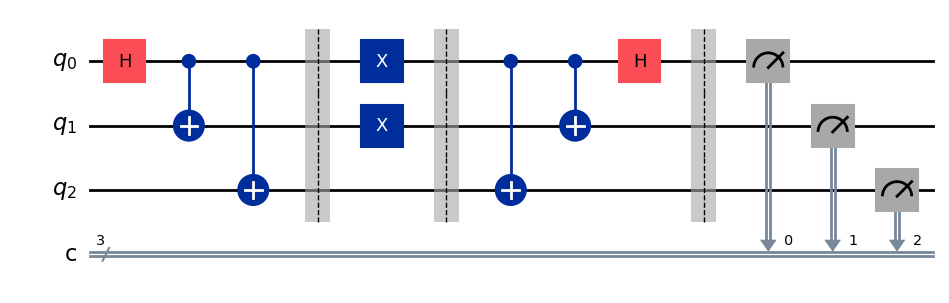

In [5]:
qc.draw(output="mpl")

{'000': 0, '001': 0, '010': 0, '011': 0, '100': 1024, '101': 0, '110': 0, '111': 0}


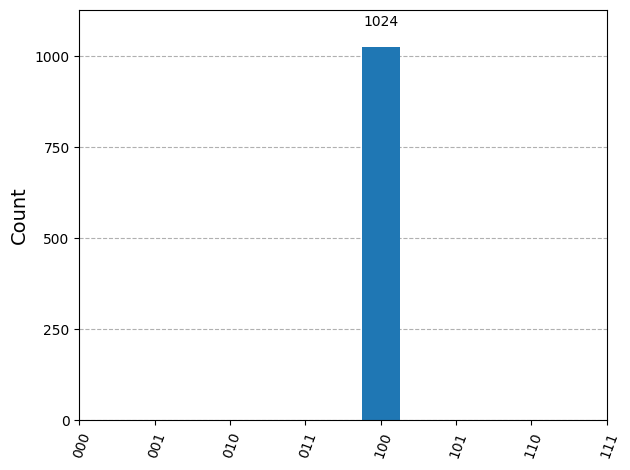

In [6]:
simulator = Aer.get_backend('qasm_simulator')

result = simulator.run(qc, shots=1024).result()
counts = result.get_counts()

# Add missing states with zero counts
all_states = ['000', '001', '010', '011', '100', '101', '110', '111']

counts_complete = {state: counts.get(state, 0) for state in all_states}

print(counts_complete)

plot_histogram(counts_complete)